# Feature Engineering for Non-Linear Regression

This notebook goes over the results shown in Lecture 9. It uses the NYC Taxi dataset. This notebook is divided into the following sections:



*   Overview of the NYC Taxi Dataset
*   Adding Interaction Terms
*   Piecewise-Linear
*   Polynomial Terms
*   Extension to Splines (Smooth)
*   Final Model




## Import Libraries & Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix, roc_auc_score, roc_curve, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
np.random.seed(25)

# Run this cell
def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    elif p < 0.1:
        return '.'
    else:
        return ''

def print_summary_with_stars(model):
    summary = model.summary2()
    coef_table = summary.tables[1].copy()

    coef_table['Signif'] = coef_table['P>|t|'].apply(significance_stars)

    numeric_columns = coef_table.select_dtypes(include=['float64', 'int64']).columns
    coef_table[numeric_columns] = coef_table[numeric_columns].round(2)
    coef_str = coef_table.to_string(index=True)

    # Determine max width
    other_texts = [
        "Regression Results",
        "Significance codes: '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1",
        f"R-squared: {model.rsquared:.2f}",
        f"Adjusted R-squared: {model.rsquared_adj:.2f}",
        f"No. Observations: {int(model.nobs)}",
    ]
    max_width = max(
        max(len(line) for line in coef_str.splitlines()),
        *(len(t) for t in other_texts)
    )

    def line(char="="):
        return char * max_width

    # Print nicely formatted summary
    print(line("="))
    print("Regression Results")
    print(line("="))

    print(f"R-squared: {model.rsquared:.2f}")
    print(f"Adjusted R-squared: {model.rsquared_adj:.2f}")
    print(f"No. Observations: {int(model.nobs)}")

    print(line("="))
    print("Coefficients:")
    print(line("-"))
    print(coef_str)
    print(line("="))
    print("Significance codes: '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1")
    print(line("="))


## Overview of the NYC Taxi Dataset

In [2]:
nyc_train = pd.read_csv('nyc_train.csv')
nyc_test = pd.read_csv('nyc_test.csv')

nyc_train['day'] = pd.Categorical(nyc_train['day'], categories=["Weekday","Friday","Saturday","Sunday"], ordered=True)
nyc_test['day'] = pd.Categorical(nyc_test['day'], categories=["Weekday","Friday","Saturday","Sunday"], ordered=True)

nyc_train_weekday = nyc_train[nyc_train['day'] == 'Weekday'].copy()
nyc_test_weekday  = nyc_test[nyc_test['day'] == 'Weekday'].copy()

display(nyc_train_weekday.head(10))

,hour,pickups,day
0,0.00,2161,Weekday
1,0.25,1747,Weekday
2,0.50,1620,Weekday
3,0.75,1428,Weekday
4,1.00,1161,Weekday
5,1.25,1010,Weekday
6,1.50,925,Weekday
7,1.75,850,Weekday
8,2.00,739,Weekday
9,2.25,607,Weekday


### Visualizations

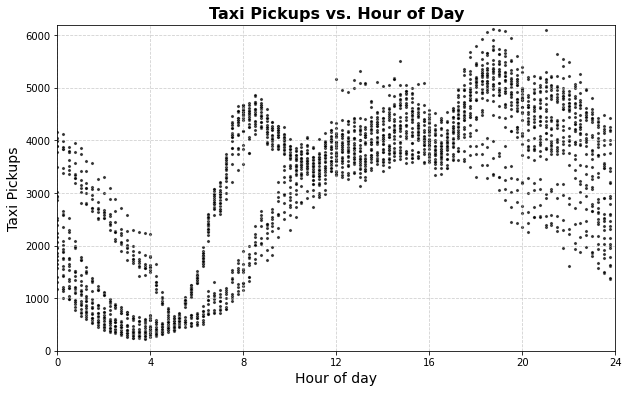

In [3]:
# Pickups Overall (All Days of the Week) scatter plot
plt.figure(figsize=(10,6))
sns.scatterplot(x='hour', y='pickups', data=nyc_train, s=10, color='black', alpha=0.8)
plt.title("Taxi Pickups vs. Hour of Day", fontsize=16, fontweight='bold')
plt.xlabel("Hour of day", fontsize=14)
plt.ylabel("Taxi Pickups", fontsize=14)
plt.xticks(ticks=np.arange(0, 25, 4))
plt.yticks(ticks=np.arange(0, 6201, 1000))
plt.xlim(0, 24)
plt.ylim(0, 6200)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

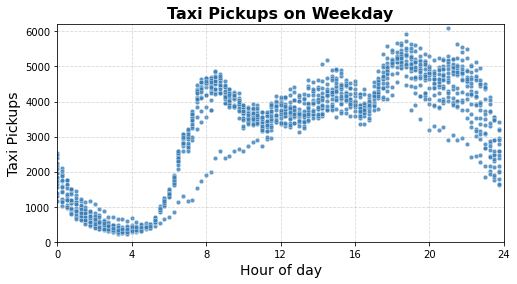

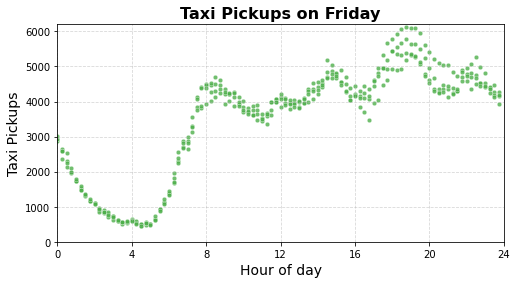

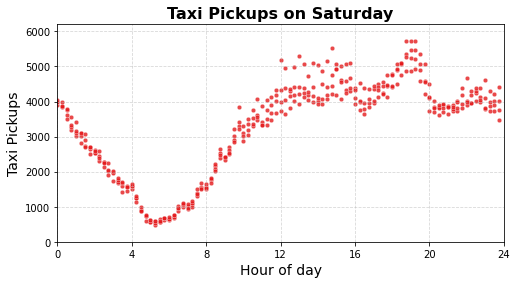

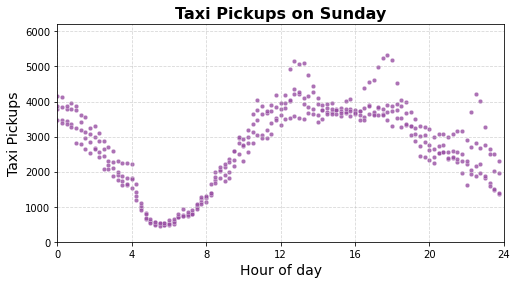

In [4]:
# Pickups by Day of the Week scatter plots
labels = ["Weekday","Friday","Saturday","Sunday"]
colors = ["#377EB8", "#4DAF4A", "#E41A1C", "#984EA3"]
for i in range(4):
  weekday_data = nyc_train[nyc_train['day'] == labels[i]]
  plt.figure(figsize=(8,4))
  sns.scatterplot(x='hour', y='pickups', data=weekday_data, s=20, color=colors[i], alpha=0.8)

  plt.xlabel("Hour of day", fontsize=14)
  plt.ylabel("Taxi Pickups", fontsize=14)
  plt.xticks(ticks=np.arange(0, 25, 4))
  plt.yticks(ticks=np.arange(0, 6201, 1000))
  plt.xlim(0, 24)
  plt.ylim(0, 6200)
  plt.title(f"Taxi Pickups on {labels[i]}", fontsize = 16, fontweight = "bold")
  plt.grid(True, linestyle="--", alpha=0.5)
  plt.show()

### Baseline Models


*   Linear Regression with hour only
*   Linear Regression with hour + day (as categorical variable)






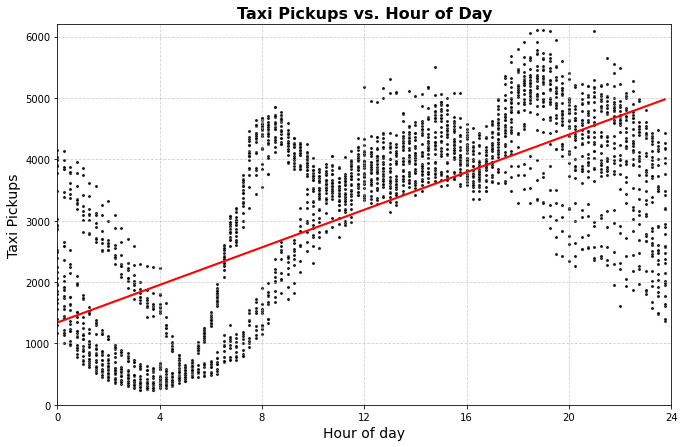

In [5]:
# Linear regression with hour only
model_hour = smf.ols('pickups ~ hour', data = nyc_train).fit()
train_dummy = nyc_train.copy()
train_dummy['preds'] = model_hour.predict(train_dummy)

plt.figure(figsize=(11,7))
sns.scatterplot(x='hour', y='pickups', data=train_dummy, s=10, color='black', alpha=0.9)
sns.lineplot(x='hour', y='preds', data=train_dummy, color="red", linewidth=2)

plt.title("Taxi Pickups vs. Hour of Day", fontsize=16, fontweight='bold')
plt.xlabel("Hour of day", fontsize=14)
plt.ylabel("Taxi Pickups", fontsize=14)
plt.xticks(ticks=np.arange(0, 25, 4))
plt.yticks(ticks=np.arange(0, 6201, 1000))
plt.xlim(0, 24)
plt.ylim(0, 6200)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [6]:
print_summary_with_stars(model_hour)

Regression Results
R-squared: 0.48
Adjusted R-squared: 0.48
No. Observations: 2688
Coefficients:
------------------------------------------------------------------
             Coef.  Std.Err.     t  P>|t|   [0.025   0.975] Signif
Intercept  1341.51     41.92  32.0    0.0  1259.30  1423.71    ***
hour        153.09      3.05  50.2    0.0   147.11   159.06    ***
Significance codes: '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1


In [7]:
# Linear regression with hour + day (as categorical variable)
model_day = smf.ols('pickups ~ hour + day', data = nyc_train).fit()
print_summary_with_stars(model_day)

Regression Results
R-squared: 0.50
Adjusted R-squared: 0.50
No. Observations: 2688
Coefficients:
-------------------------------------------------------------------------
                   Coef.  Std.Err.      t  P>|t|   [0.025   0.975] Signif
Intercept        1337.98     44.95  29.77   0.00  1249.84  1426.11    ***
day[T.Friday]     327.46     61.41   5.33   0.00   207.05   447.86    ***
day[T.Saturday]   117.56     61.41   1.91   0.06    -2.85   237.96      .
day[T.Sunday]    -420.31     61.41  -6.84   0.00  -540.72  -299.90    ***
hour              153.09      3.00  51.09   0.00   147.21   158.96    ***
Significance codes: '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1


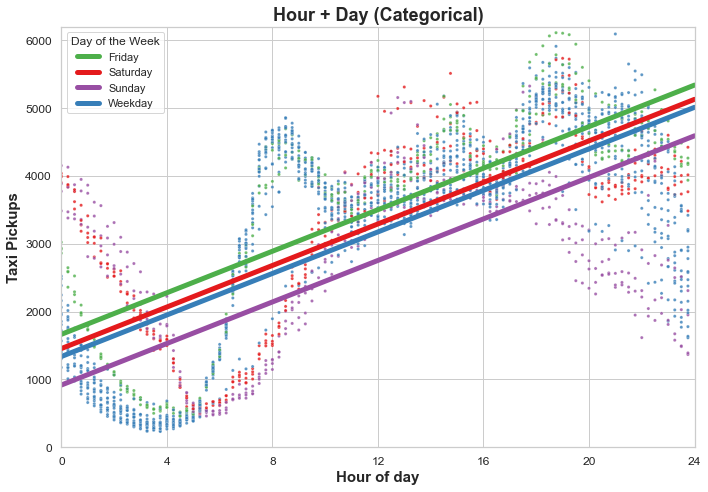

In [8]:
# Plot the models with different intercepts based on day
sns.set_theme(style="whitegrid")
labels = ['Friday', 'Saturday', 'Sunday', 'Weekday']
palette = {
    'Friday':   "#4DAF4A",
    'Saturday': "#E41A1C",
    'Sunday':   "#984EA3",
    'Weekday':  "#377EB8",
}

train_dummy = nyc_train.copy()
train_dummy['day'] = pd.Categorical(nyc_train['day'], categories=labels, ordered=True)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=train_dummy,x='hour', y='pickups',hue='day', hue_order=labels, palette=palette,s=10, alpha=0.8, legend=False)
hours = np.linspace(0, 24, 200)
for d in labels:
    grid = pd.DataFrame({'hour': hours, 'day': d})
    yhat = model_day.predict(grid)
    plt.plot(hours, yhat, lw=5, label=d, color=palette[d],)

# Axis formatting and title
plt.xlabel('Hour of day', fontsize=15, fontweight='bold')
plt.ylabel('Taxi Pickups', fontsize=15, fontweight='bold')
plt.xlim(0, 24); plt.xticks(range(0, 25, 4), fontsize=12)
plt.ylim(0, 6200); plt.yticks(range(0, 6201, 1000), fontsize=12)
plt.title('Hour + Day (Categorical)', fontsize=18, fontweight='bold')

# Legend (for the lines)
plt.legend(title='Day of the Week', frameon=True)
plt.tight_layout()
plt.show()

## Adding Interaction Terms


In [9]:
# Create interaction columns in training set
nyc_train["hour_Fri"] = nyc_train["hour"] * (nyc_train["day"] == "Friday")
nyc_train["hour_Sat"] = nyc_train["hour"] * (nyc_train["day"] == "Saturday")
nyc_train["hour_Sun"] = nyc_train["hour"] * (nyc_train["day"] == "Sunday")

# Create interaction columns in test set
nyc_test["hour_Fri"] = nyc_test["hour"] * (nyc_test["day"] == "Friday")
nyc_test["hour_Sat"] = nyc_test["hour"] * (nyc_test["day"] == "Saturday")
nyc_test["hour_Sun"] = nyc_test["hour"] * (nyc_test["day"] == "Sunday")

# Show first few rows of train set
display(nyc_train.head(6))
display(nyc_test.head(6))

,hour,pickups,day,hour_Fri,hour_Sat,hour_Sun
0,0.00,2161,Weekday,0.0,0.0,0.0
1,0.25,1747,Weekday,0.0,0.0,0.0
2,0.50,1620,Weekday,0.0,0.0,0.0
3,0.75,1428,Weekday,0.0,0.0,0.0
4,1.00,1161,Weekday,0.0,0.0,0.0
5,1.25,1010,Weekday,0.0,0.0,0.0


,hour,pickups,day,hour_Fri,hour_Sat,hour_Sun
0,0.00,2388,Weekday,0.0,0.0,0.0
1,0.25,2053,Weekday,0.0,0.0,0.0
2,0.50,1720,Weekday,0.0,0.0,0.0
3,0.75,1447,Weekday,0.0,0.0,0.0
4,1.00,1308,Weekday,0.0,0.0,0.0
5,1.25,1131,Weekday,0.0,0.0,0.0


In [10]:
model_interaction = smf.ols('pickups ~ hour + day + hour_Fri + hour_Sat + hour_Sun', data = nyc_train).fit()
print_summary_with_stars(model_interaction)

Regression Results
R-squared: 0.54
Adjusted R-squared: 0.54
No. Observations: 2688
Coefficients:
------------------------------------------------------------------------
                   Coef.  Std.Err.      t  P>|t|  [0.025   0.975] Signif
Intercept        1072.70     52.30  20.51   0.00  970.16  1175.25    ***
day[T.Friday]     228.76    116.94   1.96   0.05   -0.54   458.06      .
day[T.Saturday]   607.03    116.94   5.19   0.00  377.74   836.33    ***
day[T.Sunday]    1045.81    116.94   8.94   0.00  816.51  1275.10    ***
hour              175.42      3.80  46.12   0.00  167.97   182.88    ***
hour_Fri            8.31      8.51   0.98   0.33   -8.37    24.99       
hour_Sat          -41.22      8.51  -4.85   0.00  -57.90   -24.54    ***
hour_Sun         -123.46      8.51 -14.52   0.00 -140.14  -106.78    ***
Significance codes: '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1


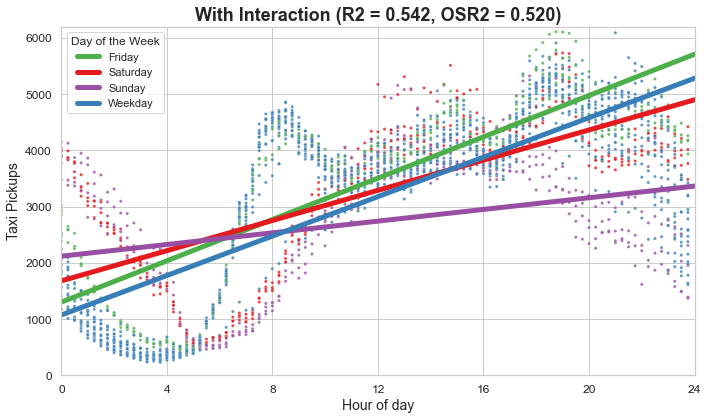

In [11]:
# Create explicit interaction columns in DataFrame
def add_manual_interactions(df):
    df = df.copy()
    df['hour_Fri'] = df['hour'] * (df['day'] == 'Friday').astype(int)
    df['hour_Sat'] = df['hour'] * (df['day'] == 'Saturday').astype(int)
    df['hour_Sun'] = df['hour'] * (df['day'] == 'Sunday').astype(int)
    return df
nyc_train_m = add_manual_interactions(nyc_train)
nyc_test_m  = add_manual_interactions(nyc_test)

# Weekday is the reference; C(day) adds day-specific intercepts
model = model_interaction
r2 = model.rsquared

# OSR^2
y_test = nyc_test_m['pickups'].to_numpy()
ybar_train = nyc_train_m['pickups'].mean()
yhat_test = model.predict(nyc_test_m)   # must pass DataFrame with all columns
sse = np.sum((y_test - yhat_test) ** 2)
sst = np.sum((y_test - ybar_train) ** 2)
osr2 = 1 - sse / sst

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=nyc_train_m, x='hour', y='pickups', hue='day', hue_order=labels, palette=palette, s=10, alpha=0.8, legend=False)
hours = np.linspace(0, 24, 200)

for d in labels:
    grid = pd.DataFrame({
        'hour': hours,
        'day': d
    })
    grid = add_manual_interactions(grid)
    yhat = model.predict(grid)
    plt.plot(hours, yhat, lw=5, color=palette[d], label=d)

plt.xlabel('Hour of day', fontsize=14)
plt.ylabel('Taxi Pickups', fontsize=14)
plt.xlim(0, 24); plt.xticks(range(0, 26, 4), fontsize=12)
plt.ylim(0, 6200); plt.yticks(range(0, 6210, 1000), fontsize=12)
plt.title(f'With Interaction (R2 = {r2:.3f}, OSR2 = {osr2:.3f})',fontsize=18, fontweight='bold')
plt.legend(title='Day of the Week', frameon=True)
plt.tight_layout()
plt.show()


## Piecewise-Linear
From adding interaction terms, we see that we can essentially fit separate lines for each day of the week. Let's work on getting a better fit for weekdays.

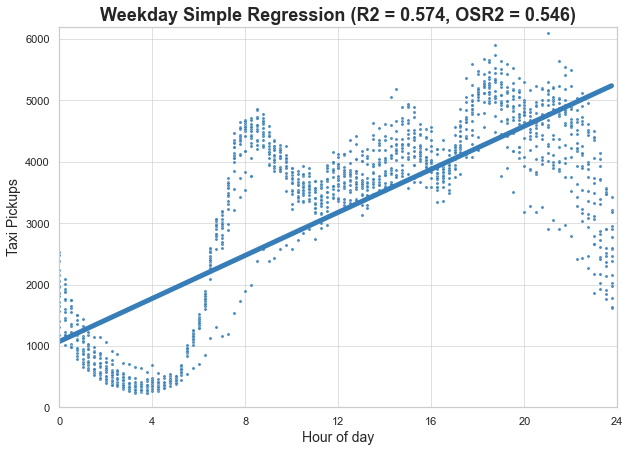

In [12]:
# Plotting a simple linear regression on weekday data (clearly not a good fit)
model_weekday = smf.ols('pickups ~ hour', data = nyc_train_weekday).fit()
model = model_weekday
r2 = model.rsquared

# OSR^2
y_test = nyc_test_weekday['pickups'].to_numpy()
ybar_train = nyc_train_weekday['pickups'].mean()
yhat_test = model.predict(nyc_test_weekday)
sse = np.sum((y_test - yhat_test) ** 2)
sst = np.sum((y_test - ybar_train) ** 2)
osr2 = 1 - sse / sst

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(data=nyc_train_weekday, x='hour', y='pickups', s=10, color='#377EB8', alpha = 0.9)
sns.lineplot(x='hour', y=model.predict(nyc_train_weekday), data=nyc_train_weekday, color="#377EB8", linewidth=5)

plt.title(f'Weekday Simple Regression (R2 = {r2:.3f}, OSR2 = {osr2:.3f})',fontsize=18, fontweight='bold')
plt.xlabel("Hour of day", fontsize=14)
plt.ylabel("Taxi Pickups", fontsize=14)
plt.xticks(ticks=np.arange(0, 25, 4))
plt.yticks(ticks=np.arange(0, 6201, 1000))
plt.xlim(0, 24)
plt.ylim(0, 6200)
plt.grid(True, alpha=0.6)
plt.show()



Let's try breaking the line at hour = 5, 9, and 19.

In [13]:
# Feature Engineering (adding extra columns)
nyc_train_pl = nyc_train_weekday.copy()
nyc_test_pl = nyc_test_weekday.copy()
nyc_train_pl['hour_after_5'] = np.maximum(nyc_train_pl['hour'] - 5, 0)
nyc_train_pl['hour_after_9'] = np.maximum(nyc_train_pl['hour'] - 9, 0)
nyc_train_pl['hour_after_19'] = np.maximum(nyc_train_pl['hour'] - 19, 0)

nyc_test_pl['hour_after_5'] = np.maximum(nyc_test_pl['hour'] - 5, 0)
nyc_test_pl['hour_after_9'] = np.maximum(nyc_test_pl['hour'] - 9, 0)
nyc_test_pl['hour_after_19'] = np.maximum(nyc_test_pl['hour'] - 19, 0)

display(nyc_train_pl.head(6))
display(nyc_test_pl.tail(6))


,hour,pickups,day,hour_after_5,hour_after_9,hour_after_19
0,0.00,2161,Weekday,0.0,0.0,0.0
1,0.25,1747,Weekday,0.0,0.0,0.0
2,0.50,1620,Weekday,0.0,0.0,0.0
3,0.75,1428,Weekday,0.0,0.0,0.0
4,1.00,1161,Weekday,0.0,0.0,0.0
5,1.25,1010,Weekday,0.0,0.0,0.0


,hour,pickups,day,hour_after_5,hour_after_9,hour_after_19
2774,22.50,4514,Weekday,17.50,13.50,3.50
2775,22.75,4669,Weekday,17.75,13.75,3.75
2776,23.00,4526,Weekday,18.00,14.00,4.00
2777,23.25,4188,Weekday,18.25,14.25,4.25
2778,23.50,3774,Weekday,18.50,14.50,4.50
2779,23.75,3665,Weekday,18.75,14.75,4.75


In [14]:
# Plotting model
model_pl = smf.ols('pickups ~ hour + hour_after_5 + hour_after_9 + hour_after_19', data = nyc_train_pl).fit()
print_summary_with_stars(model_pl)

Regression Results
R-squared: 0.85
Adjusted R-squared: 0.85
No. Observations: 1536
Coefficients:
----------------------------------------------------------------------
                 Coef.  Std.Err.      t  P>|t|  [0.025   0.975] Signif
Intercept      1099.65     62.41  17.62    0.0  977.24  1222.07    ***
hour           -105.77     18.49  -5.72    0.0 -142.03   -69.51    ***
hour_after_5    934.08     32.40  28.83    0.0  870.53   997.64    ***
hour_after_9   -747.45     21.74 -34.37    0.0 -790.10  -704.80    ***
hour_after_19  -354.13     21.78 -16.26    0.0 -396.85  -311.40    ***
Significance codes: '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1


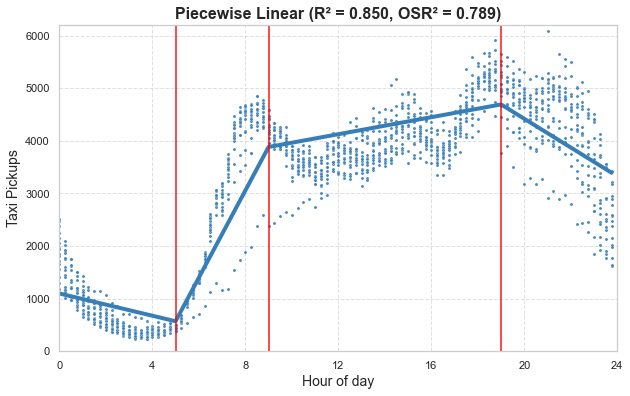

In [15]:
# Plotting model with piece-wise line
weekday_train_dummy = nyc_train_pl.copy()
weekday_train_dummy['preds'] = model_pl.predict(weekday_train_dummy)
weekday_test_dummy = nyc_test_pl.copy()
weekday_test_dummy['preds'] = model_pl.predict(weekday_test_dummy)

r2 = model_pl.rsquared
osr2 = 1 - np.sum((weekday_test_dummy['preds'] - weekday_test_dummy['pickups'])**2) / np.sum((weekday_train_dummy['pickups'].mean() - weekday_test_dummy['pickups'])**2)

plt.figure(figsize=(10,6))
sns.scatterplot(x='hour', y='pickups', data=weekday_train_dummy, s=10, color='#377EB8', alpha=0.9)
sns.lineplot(x='hour', y='preds', data=weekday_train_dummy, color="#377EB8", linewidth=4)
plt.title(f"Piecewise Linear (R² = {r2:.3f}, OSR² = {osr2:.3f})", fontsize=16, fontweight='bold')
plt.xlabel("Hour of day", fontsize=14)
plt.ylabel("Taxi Pickups", fontsize=14)
plt.xticks(ticks=np.arange(0, 25, 4))
plt.yticks(ticks=np.arange(0, 6201, 1000))
plt.xlim(0, 24)
plt.ylim(0, 6200)
plt.grid(True, linestyle="--", alpha=0.6)
for x in [5, 9, 19]:
  plt.axvline(x=x, color='red', alpha=0.7, linewidth=2)
plt.show()


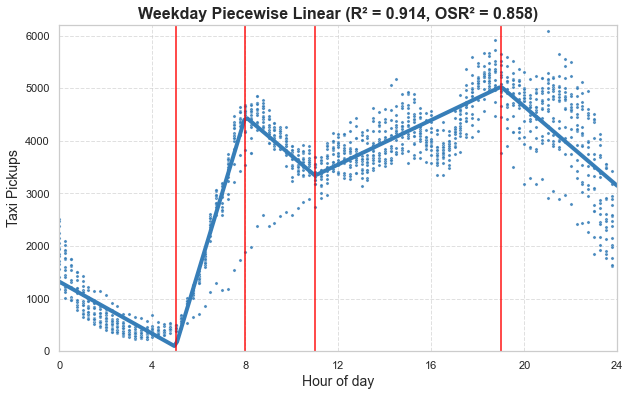

In [16]:
# Different breaking points (5, 8, 11, 19)
nyc_train_pl['hour_after_8'] = np.maximum(nyc_train_pl['hour'] - 8, 0)
nyc_train_pl['hour_after_11'] = np.maximum(nyc_train_pl['hour'] - 11, 0)
nyc_test_pl['hour_after_8'] = np.maximum(nyc_test_pl['hour'] - 8, 0)
nyc_test_pl['hour_after_11'] = np.maximum(nyc_test_pl['hour'] - 11, 0)
model_pl2 = smf.ols('pickups ~ hour + hour_after_5 + hour_after_8 + hour_after_11 + hour_after_19', data = nyc_train_pl).fit()

# Create a smooth grid of hours for plotting
hours_grid = np.linspace(0, 24, 200)
grid_df = pd.DataFrame({'hour': hours_grid})

# Add the same piecewise variables for the grid
grid_df['hour_after_5']  = np.maximum(grid_df['hour'] - 5, 0)
grid_df['hour_after_8']  = np.maximum(grid_df['hour'] - 8, 0)
grid_df['hour_after_11'] = np.maximum(grid_df['hour'] - 11, 0)
grid_df['hour_after_19'] = np.maximum(grid_df['hour'] - 19, 0)
yhat_grid = model_pl2.predict(grid_df)

# OSR^2
r2 = model_pl2.rsquared
y_test = nyc_test_pl['pickups'].to_numpy()
ybar_train = nyc_train_pl['pickups'].mean()
yhat_test = model_pl2.predict(nyc_test_pl)
sse = np.sum((y_test - yhat_test) ** 2)
sst = np.sum((y_test - ybar_train) ** 2)
osr2 = 1 - sse / sst

plt.figure(figsize=(10,6))
sns.scatterplot(x='hour', y='pickups', data=nyc_train_pl, s=10, color='#377EB8', alpha=0.9)
sns.lineplot(x=hours_grid, y=yhat_grid, color="#377EB8", linewidth=4)
plt.title(f"Weekday Piecewise Linear (R² = {r2:.3f}, OSR² = {osr2:.3f})", fontsize=16, fontweight='bold')
plt.xlabel("Hour of day", fontsize=14)
plt.ylabel("Taxi Pickups", fontsize=14)
plt.xticks(ticks=np.arange(0, 25, 4))
plt.yticks(ticks=np.arange(0, 6201, 1000))
plt.xlim(0, 24)
plt.ylim(0, 6200)
plt.grid(True, linestyle="--", alpha=0.6)
for x in [5, 8, 11, 19]:
  plt.axvline(x=x, color='red', alpha=0.7, linewidth=2)
plt.show()

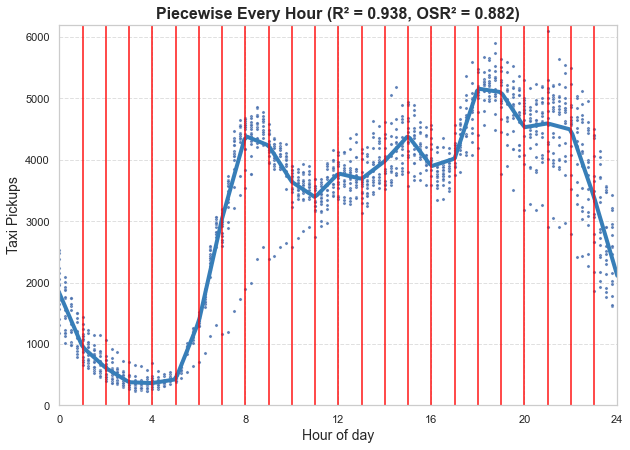

In [17]:
# Breaking point at every hour
def add_piecewise_hours(df, knots):
  df = df.copy()
  for k in knots:
    df[f'hour_after_{k}'] = np.maximum(df['hour'] - k, 0)
  return df

def build_formula(base_var, knots):
  rhs = [base_var] + [f'hour_after_{k}' for k in knots]
  return 'pickups ~ ' + '+'.join(rhs)

knots = list(range(1,24))
nyc_train_weekday_m = add_piecewise_hours(nyc_train_weekday, knots)
nyc_test_weekday_m = add_piecewise_hours(nyc_test_weekday, knots)
formula = build_formula('hour',knots)
model_pl_all = smf.ols(formula, data = nyc_train_weekday_m).fit()
r2 = model_pl_all.rsquared

#OSR^2
y_test = nyc_test_weekday_m['pickups'].to_numpy()
ybar_train = nyc_train_weekday_m['pickups'].mean()
yhat_test = model_pl_all.predict(nyc_test_weekday_m)
sse = np.sum((y_test - yhat_test) ** 2)
sst = np.sum((y_test - ybar_train) ** 2)
osr2 = 1 - sse / sst

#Plotting
hours_grid = np.linspace(0, 24, 200)
grid_df = pd.DataFrame({'hour': hours_grid})
grid_df = add_piecewise_hours(grid_df, knots)
yhat_grid = model_pl_all.predict(grid_df)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=nyc_train_weekday_m, x='hour', y='pickups', s=10, alpha=0.9)
sns.lineplot(x=hours_grid, y=yhat_grid, color="#377EB8", linewidth=4)

plt.title(f'Piecewise Every Hour 'f'(R² = {r2:.3f}, OSR² = {osr2:.3f})',fontsize=16, fontweight='bold')
plt.xlabel('Hour of day', fontsize=14)
plt.ylabel('Taxi Pickups', fontsize=14)
plt.xticks(np.arange(0, 25, 4))
plt.yticks(np.arange(0, 6201, 1000))
plt.xlim(0, 24); plt.ylim(0, 6200)
plt.grid(True, linestyle='--', alpha=0.6)
for x in [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23]:
  plt.axvline(x=x, color='red', alpha=0.7, linewidth=2)
plt.show()

In [18]:
print_summary_with_stars(model_pl_all)

Regression Results
R-squared: 0.94
Adjusted R-squared: 0.94
No. Observations: 1536
Coefficients:
-----------------------------------------------------------------------
                 Coef.  Std.Err.      t  P>|t|   [0.025   0.975] Signif
Intercept      1828.91     76.75  23.83   0.00  1678.35  1979.47    ***
hour           -878.49    113.90  -7.71   0.00 -1101.90  -655.08    ***
hour_after_1    536.01    193.58   2.77   0.01   156.30   915.72     **
hour_after_2    110.64    183.26   0.60   0.55  -248.83   470.12       
hour_after_3    217.38    182.65   1.19   0.23  -140.89   575.65       
hour_after_4     75.62    182.61   0.41   0.68  -282.58   433.82       
hour_after_5    882.78    182.61   4.83   0.00   524.58  1240.97    ***
hour_after_6    734.45    182.61   4.02   0.00   376.26  1092.65    ***
hour_after_7   -335.57    182.61  -1.84   0.07  -693.76    22.63      .
hour_after_8  -1497.03    182.61  -8.20   0.00 -1855.23 -1138.84    ***
hour_after_9   -439.79    182.61  -2.41

## Polynomial Terms

In [19]:
# Feature Engineering (Add New Columns)
nyc_train_poly = nyc_train_weekday.copy()
nyc_test_poly = nyc_test_weekday.copy()

nyc_train_poly['hour_2'] = nyc_train_poly['hour'] ** 2
nyc_train_poly['hour_3'] = nyc_train_poly['hour'] ** 3
nyc_train_poly['hour_4'] = nyc_train_poly['hour'] ** 4
nyc_train_poly['hour_5'] = nyc_train_poly['hour'] ** 5

nyc_test_poly['hour_2'] = nyc_test_poly['hour'] ** 2
nyc_test_poly['hour_3'] = nyc_test_poly['hour'] ** 3
nyc_test_poly['hour_4'] = nyc_test_poly['hour'] ** 4
nyc_test_poly['hour_5'] = nyc_test_poly['hour'] ** 5

display(nyc_train_poly.head(10))

,hour,pickups,day,hour_2,hour_3,hour_4,hour_5
0,0.00,2161,Weekday,0.0000,0.000000,0.000000,0.000000
1,0.25,1747,Weekday,0.0625,0.015625,0.003906,0.000977
2,0.50,1620,Weekday,0.2500,0.125000,0.062500,0.031250
3,0.75,1428,Weekday,0.5625,0.421875,0.316406,0.237305
4,1.00,1161,Weekday,1.0000,1.000000,1.000000,1.000000
5,1.25,1010,Weekday,1.5625,1.953125,2.441406,3.051758
6,1.50,925,Weekday,2.2500,3.375000,5.062500,7.593750
7,1.75,850,Weekday,3.0625,5.359375,9.378906,16.413086
8,2.00,739,Weekday,4.0000,8.000000,16.000000,32.000000
9,2.25,607,Weekday,5.0625,11.390625,25.628906,57.665039


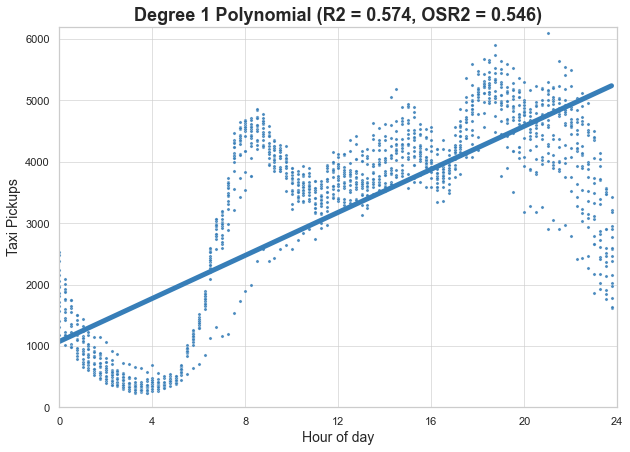

In [20]:
# Degree one (same as simple linear regression)
model_deg1 = smf.ols('pickups ~ hour', data = nyc_train_weekday).fit()
model = model_deg1
r2 = model.rsquared

# OSR^2
y_test = nyc_test_weekday['pickups'].to_numpy()
ybar_train = nyc_train_weekday['pickups'].mean()
yhat_test = model.predict(nyc_test_weekday)
sse = np.sum((y_test - yhat_test) ** 2)
sst = np.sum((y_test - ybar_train) ** 2)
osr2 = 1 - sse / sst

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(data=nyc_train_weekday, x='hour', y='pickups', s=10, color='#377EB8', alpha = 0.9)
sns.lineplot(x='hour', y=model.predict(nyc_train_weekday), data=nyc_train_weekday, color="#377EB8", linewidth=5)

plt.title(f'Degree 1 Polynomial (R2 = {r2:.3f}, OSR2 = {osr2:.3f})',fontsize=18, fontweight='bold')
plt.xlabel("Hour of day", fontsize=14)
plt.ylabel("Taxi Pickups", fontsize=14)
plt.xticks(ticks=np.arange(0, 25, 4))
plt.yticks(ticks=np.arange(0, 6201, 1000))
plt.xlim(0, 24)
plt.ylim(0, 6200)
plt.grid(True, alpha=0.6)
plt.show()


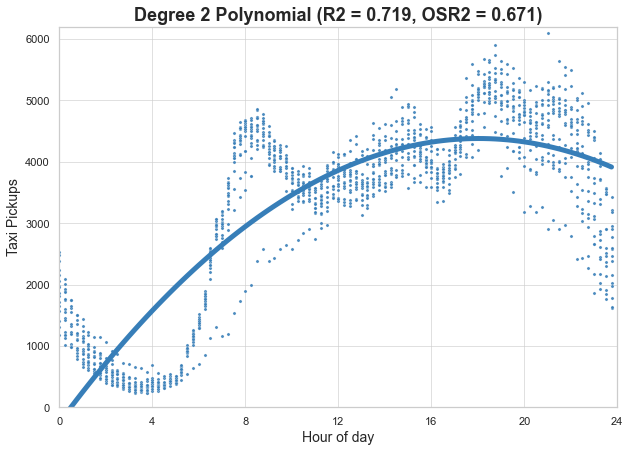

In [21]:
# Degree 2 polynomial
model_deg2 = smf.ols('pickups ~ hour + hour_2', data = nyc_train_poly).fit()
model = model_deg2
r2 = model.rsquared

# OSR^2
y_test = nyc_test_poly['pickups'].to_numpy()
ybar_train = nyc_train_poly['pickups'].mean()
yhat_test = model.predict(nyc_test_poly)
sse = np.sum((y_test - yhat_test) ** 2)
sst = np.sum((y_test - ybar_train) ** 2)
osr2 = 1 - sse / sst

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(data=nyc_train_poly, x='hour', y='pickups', s=10, color='#377EB8', alpha = 0.9)
sns.lineplot(x='hour', y=model.predict(nyc_train_poly), data=nyc_train_poly, color="#377EB8", linewidth=5)

plt.title(f'Degree 2 Polynomial (R2 = {r2:.3f}, OSR2 = {osr2:.3f})',fontsize=18, fontweight='bold')
plt.xlabel("Hour of day", fontsize=14)
plt.ylabel("Taxi Pickups", fontsize=14)
plt.xticks(ticks=np.arange(0, 25, 4))
plt.yticks(ticks=np.arange(0, 6201, 1000))
plt.xlim(0, 24)
plt.ylim(0, 6200)
plt.grid(True, alpha=0.6)
plt.show()

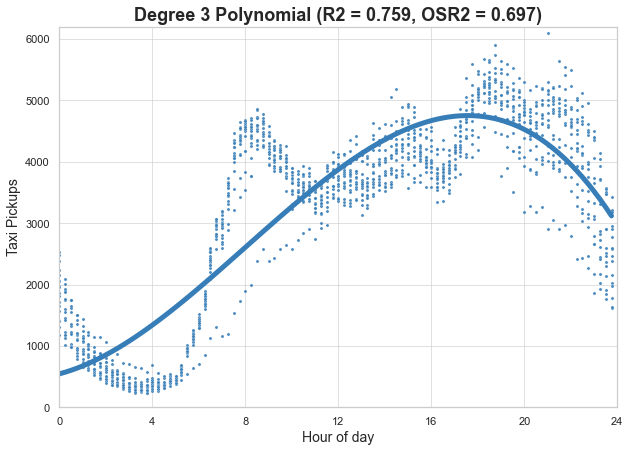

In [22]:
# Degree 3 polynomial
model_deg2 = smf.ols('pickups ~ hour + hour_2 + hour_3', data = nyc_train_poly).fit()
model = model_deg2
r2 = model.rsquared

# OSR^2
y_test = nyc_test_poly['pickups'].to_numpy()
ybar_train = nyc_train_poly['pickups'].mean()
yhat_test = model.predict(nyc_test_poly)
sse = np.sum((y_test - yhat_test) ** 2)
sst = np.sum((y_test - ybar_train) ** 2)
osr2 = 1 - sse / sst

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(data=nyc_train_poly, x='hour', y='pickups', s=10, color='#377EB8', alpha = 0.9)
sns.lineplot(x='hour', y=model.predict(nyc_train_poly), data=nyc_train_poly, color="#377EB8", linewidth=5)

plt.title(f'Degree 3 Polynomial (R2 = {r2:.3f}, OSR2 = {osr2:.3f})',fontsize=18, fontweight='bold')
plt.xlabel("Hour of day", fontsize=14)
plt.ylabel("Taxi Pickups", fontsize=14)
plt.xticks(ticks=np.arange(0, 25, 4))
plt.yticks(ticks=np.arange(0, 6201, 1000))
plt.xlim(0, 24)
plt.ylim(0, 6200)
plt.grid(True, alpha=0.6)
plt.show()

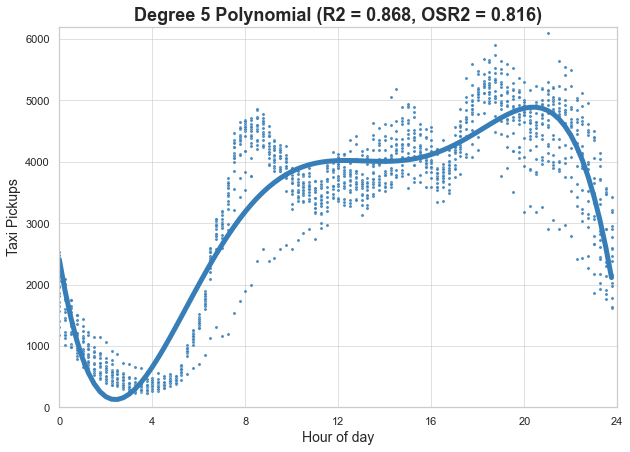

In [23]:
# Degree 5 polynomial
model_deg2 = smf.ols('pickups ~ hour + hour_2 + hour_3 + hour_4 + hour_5', data = nyc_train_poly).fit()
model = model_deg2
r2 = model.rsquared

# OSR^2
y_test = nyc_test_poly['pickups'].to_numpy()
ybar_train = nyc_train_poly['pickups'].mean()
yhat_test = model.predict(nyc_test_poly)
sse = np.sum((y_test - yhat_test) ** 2)
sst = np.sum((y_test - ybar_train) ** 2)
osr2 = 1 - sse / sst

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(data=nyc_train_poly, x='hour', y='pickups', s=10, color='#377EB8', alpha = 0.9)
sns.lineplot(x='hour', y=model.predict(nyc_train_poly), data=nyc_train_poly, color="#377EB8", linewidth=5)

plt.title(f'Degree 5 Polynomial (R2 = {r2:.3f}, OSR2 = {osr2:.3f})',fontsize=18, fontweight='bold')
plt.xlabel("Hour of day", fontsize=14)
plt.ylabel("Taxi Pickups", fontsize=14)
plt.xticks(ticks=np.arange(0, 25, 4))
plt.yticks(ticks=np.arange(0, 6201, 1000))
plt.xlim(0, 24)
plt.ylim(0, 6200)
plt.grid(True, alpha=0.6)
plt.show()

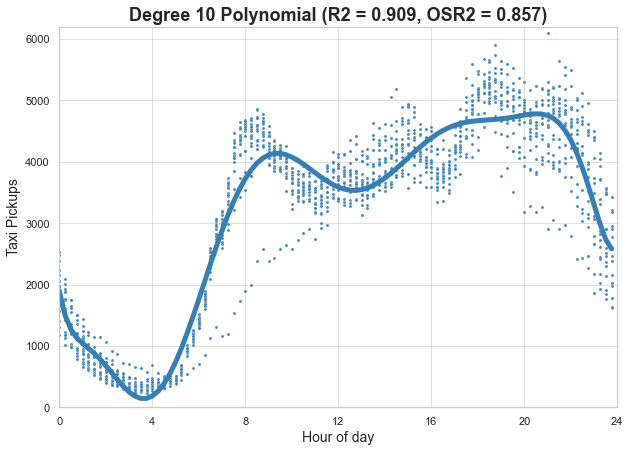

In [24]:
# Degree 10 polynomial
nyc_test_poly['hour_6'] = nyc_test_poly['hour'] ** 6
nyc_test_poly['hour_7'] = nyc_test_poly['hour'] ** 7
nyc_test_poly['hour_8'] = nyc_test_poly['hour'] ** 8
nyc_test_poly['hour_9'] = nyc_test_poly['hour'] ** 9
nyc_test_poly['hour_10'] = nyc_test_poly['hour'] ** 10

nyc_train_poly['hour_6'] = nyc_train_poly['hour'] ** 6
nyc_train_poly['hour_7'] = nyc_train_poly['hour'] ** 7
nyc_train_poly['hour_8'] = nyc_train_poly['hour'] ** 8
nyc_train_poly['hour_9'] = nyc_train_poly['hour'] ** 9
nyc_train_poly['hour_10'] = nyc_train_poly['hour'] ** 10



model_deg2 = smf.ols('pickups ~ hour + hour_2 + hour_3 + hour_4 + hour_5 + hour_6 + hour_7 + hour_8 + hour_9 + hour_10', data = nyc_train_poly).fit()
model = model_deg2
r2 = model.rsquared

# OSR^2
y_test = nyc_test_poly['pickups'].to_numpy()
ybar_train = nyc_train_poly['pickups'].mean()
yhat_test = model.predict(nyc_test_poly)
sse = np.sum((y_test - yhat_test) ** 2)
sst = np.sum((y_test - ybar_train) ** 2)
osr2 = 1 - sse / sst

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(data=nyc_train_poly, x='hour', y='pickups', s=10, color='#377EB8', alpha = 0.9)
sns.lineplot(x='hour', y=model.predict(nyc_train_poly), data=nyc_train_poly, color="#377EB8", linewidth=5)

plt.title(f'Degree 10 Polynomial (R2 = {r2:.3f}, OSR2 = {osr2:.3f})',fontsize=18, fontweight='bold')
plt.xlabel("Hour of day", fontsize=14)
plt.ylabel("Taxi Pickups", fontsize=14)
plt.xticks(ticks=np.arange(0, 25, 4))
plt.yticks(ticks=np.arange(0, 6201, 1000))
plt.xlim(0, 24)
plt.ylim(0, 6200)
plt.grid(True, alpha=0.6)
plt.show()

## Piecewise + Polynomial Together


In [25]:
# Feature Engineering (adding new columns)
nyc_train_pp = nyc_train_pl.copy()
nyc_test_pp = nyc_test_pl.copy()

nyc_train_pp['hour_2'] = nyc_train_pp['hour'] ** 2
nyc_train_pp['hour_after_5_2'] = nyc_train_pp['hour_after_5'] ** 2
nyc_train_pp['hour_after_9_2'] = nyc_train_pp['hour_after_9'] ** 2
nyc_train_pp['hour_after_19_2'] = nyc_train_pp['hour_after_19'] ** 2
nyc_test_pp['hour_2'] = nyc_test_pp['hour'] ** 2
nyc_test_pp['hour_after_5_2'] = nyc_test_pp['hour_after_5'] ** 2
nyc_test_pp['hour_after_9_2'] = nyc_test_pp['hour_after_9'] ** 2
nyc_test_pp['hour_after_19_2'] = nyc_test_pp['hour_after_19'] ** 2

display(nyc_train_pp)

,hour,pickups,day,hour_after_5,hour_after_9,hour_after_19,hour_after_8,hour_after_11,hour_2,hour_after_5_2,hour_after_9_2,hour_after_19_2
0,0.00,2161,Weekday,0.00,0.00,0.00,0.00,0.00,0.0000,0.0000,0.0000,0.0000
1,0.25,1747,Weekday,0.00,0.00,0.00,0.00,0.00,0.0625,0.0000,0.0000,0.0000
2,0.50,1620,Weekday,0.00,0.00,0.00,0.00,0.00,0.2500,0.0000,0.0000,0.0000
3,0.75,1428,Weekday,0.00,0.00,0.00,0.00,0.00,0.5625,0.0000,0.0000,0.0000
4,1.00,1161,Weekday,0.00,0.00,0.00,0.00,0.00,1.0000,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
2683,22.75,3970,Weekday,17.75,13.75,3.75,14.75,11.75,517.5625,315.0625,189.0625,14.0625
2684,23.00,3648,Weekday,18.00,14.00,4.00,15.00,12.00,529.0000,324.0000,196.0000,16.0000
2685,23.25,3389,Weekday,18.25,14.25,4.25,15.25,12.25,540.5625,333.0625,203.0625,18.0625
2686,23.50,2908,Weekday,18.50,14.50,4.50,15.50,12.50,552.2500,342.2500,210.2500,20.2500


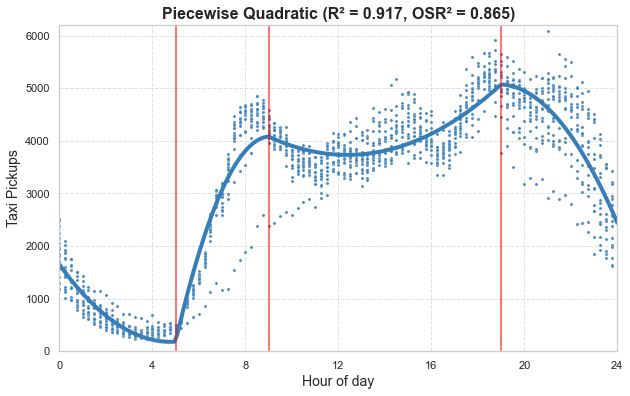

In [26]:
formula = 'pickups ~ hour + hour_2 + hour_after_5 + hour_after_5_2 + hour_after_9 + hour_after_9_2 + hour_after_19 + hour_after_19_2'
model_pq = smf.ols(formula = formula, data = nyc_train_pp).fit()
r2 = model_pq.rsquared

# OSR^2
y_test = nyc_test_pp['pickups'].to_numpy()
ybar_train = nyc_train_pp['pickups'].mean()
yhat_test = model_pq.predict(nyc_test_pp)
sse = np.sum((y_test - yhat_test)**2)
sst = np.sum((y_test - ybar_train)**2)
osr2 = 1 - sse/sst

# Plotting
hours_grid = np.linspace(0, 24, 200)
grid_df = pd.DataFrame({'hour': hours_grid})
grid_df['hour_2'] = grid_df['hour']**2
grid_df['hour_after_5'] = np.maximum(grid_df['hour'] - 5, 0)
grid_df['hour_after_5_2'] = grid_df['hour_after_5']**2
grid_df['hour_after_9'] = np.maximum(grid_df['hour'] - 9, 0)
grid_df['hour_after_9_2'] = grid_df['hour_after_9']**2
grid_df['hour_after_19'] = np.maximum(grid_df['hour'] - 19, 0)
grid_df['hour_after_19_2'] = grid_df['hour_after_19']**2

yhat_grid = model_pq.predict(grid_df)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=nyc_train_pp, x='hour', y='pickups', s=10, color='#377EB8', alpha=0.9)
sns.lineplot(x=hours_grid, y=yhat_grid, color='#377EB8', linewidth=4)

for x in [5, 9, 19]:
    plt.axvline(x=x, color='red', alpha=0.7)

plt.title(f'Piecewise Quadratic (R² = {r2:.3f}, OSR² = {osr2:.3f})', fontsize=16, fontweight='bold')
plt.xlabel("Hour of day", fontsize=14)
plt.ylabel("Taxi Pickups", fontsize=14)
plt.xticks(np.arange(0, 25, 4))
plt.yticks(np.arange(0, 6201, 1000))
plt.xlim(0, 24); plt.ylim(0, 6200)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Extension: Splines for Smoothness

In [27]:
from patsy import bs

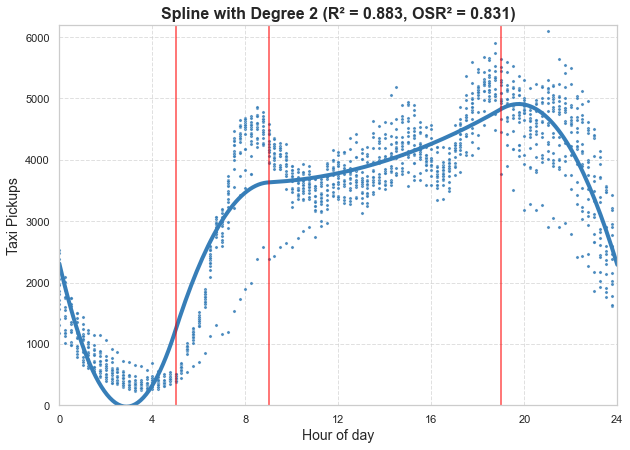

In [28]:
# Spline with degree 2 polynomial
formula = 'pickups ~ bs(hour, degree=2, knots=(5, 9, 19), lower_bound=0, upper_bound=24)'
model_spline2 = smf.ols(formula=formula, data=nyc_train_weekday).fit()
r2 = model_spline2.rsquared

# OSR²
y_test = nyc_test_weekday['pickups'].to_numpy()
ybar_train = nyc_train_weekday['pickups'].mean()
yhat_test = model_spline2.predict(nyc_test_weekday)
sse = np.sum((y_test - yhat_test)**2)
sst = np.sum((y_test - ybar_train)**2)
osr2 = 1 - sse/sst

# Plotting
hours_grid = np.linspace(0, 24, 200)
grid_df = pd.DataFrame({'hour': hours_grid})
yhat_grid = model_spline2.predict(grid_df)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=nyc_train_weekday, x='hour', y='pickups', s=10, alpha=0.9, color="#377EB8")
sns.lineplot(x=hours_grid, y=yhat_grid, color="#377EB8", linewidth=4)
for x in [5, 9, 19]:
    plt.axvline(x=x, color="red", alpha=0.7)
plt.title(f"Spline with Degree 2 (R² = {r2:.3f}, OSR² = {osr2:.3f})", fontsize=16, fontweight="bold")
plt.xlabel("Hour of day", fontsize=14)
plt.ylabel("Taxi Pickups", fontsize=14)
plt.xticks(np.arange(0, 25, 4))
plt.yticks(np.arange(0, 6201, 1000))
plt.xlim(0, 24); plt.ylim(0, 6200)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

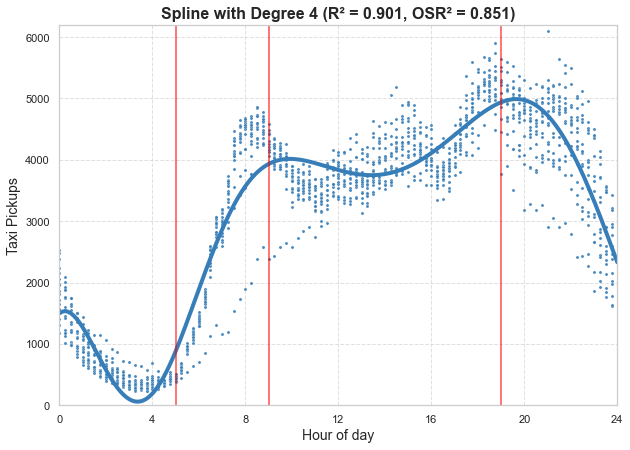

In [29]:
# Spline with degree 4 polynomial
formula = 'pickups ~ bs(hour, degree=4, knots=(5, 9, 19), lower_bound=0, upper_bound=24)'
model_spline4 = smf.ols(formula=formula, data=nyc_train_weekday).fit()
r2 = model_spline4.rsquared

# OSR²
y_test = nyc_test_weekday['pickups'].to_numpy()
ybar_train = nyc_train_weekday['pickups'].mean()
yhat_test = model_spline4.predict(nyc_test_weekday)
sse = np.sum((y_test - yhat_test)**2)
sst = np.sum((y_test - ybar_train)**2)
osr2 = 1 - sse/sst

# Plotting
hours_grid = np.linspace(0, 24, 200)
grid_df = pd.DataFrame({'hour': hours_grid})
yhat_grid = model_spline4.predict(grid_df)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=nyc_train_weekday, x='hour', y='pickups', s=10, alpha=0.9, color="#377EB8")
sns.lineplot(x=hours_grid, y=yhat_grid, color="#377EB8", linewidth=4)
for x in [5, 9, 19]:
    plt.axvline(x=x, color="red", alpha=0.7)
plt.title(f"Spline with Degree 4 (R² = {r2:.3f}, OSR² = {osr2:.3f})", fontsize=16, fontweight="bold")
plt.xlabel("Hour of day", fontsize=14)
plt.ylabel("Taxi Pickups", fontsize=14)
plt.xticks(np.arange(0, 25, 4))
plt.yticks(np.arange(0, 6201, 1000))
plt.xlim(0, 24); plt.ylim(0, 6200)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## Final Model
Let's put it all together and make a great model for all our data (all days). There is a lot of feature engineering here.

In [30]:
# Feature Engineering
def feature_engineer_all(nyc: pd.DataFrame) -> pd.DataFrame:
    nyc = nyc.copy()

    # Interactions with hour
    nyc['weekday_hour'] = nyc['hour'] * (nyc['day'] == 'Weekday')
    nyc['Fri_hour']     = nyc['hour'] * (nyc['day'] == 'Friday')
    nyc['Sat_hour']     = nyc['hour'] * (nyc['day'] == 'Saturday')
    nyc['Sun_hour']     = nyc['hour'] * (nyc['day'] == 'Sunday')

    # Weekday breakpoints
    nyc['weekday_hour_after_5']  = np.maximum(nyc['weekday_hour'] - 5, 0)
    nyc['weekday_hour_after_9']  = np.maximum(nyc['weekday_hour'] - 9, 0)
    nyc['weekday_hour_after_19'] = np.maximum(nyc['weekday_hour'] - 19, 0)

    # Friday breakpoints
    nyc['Fri_hour_after_5']  = np.maximum(nyc['Fri_hour'] - 5, 0)
    nyc['Fri_hour_after_9']  = np.maximum(nyc['Fri_hour'] - 9, 0)
    nyc['Fri_hour_after_19'] = np.maximum(nyc['Fri_hour'] - 19, 0)

    # Saturday breakpoints
    nyc['Sat_hour_after_6']  = np.maximum(nyc['Sat_hour'] - 5, 0)   # matches R naming
    nyc['Sat_hour_after_12'] = np.maximum(nyc['Sat_hour'] - 12, 0)
    nyc['Sat_hour_after_19'] = np.maximum(nyc['Sat_hour'] - 19, 0)

    # Sunday breakpoints
    nyc['Sun_hour_after_6']  = np.maximum(nyc['Sun_hour'] - 5, 0)
    nyc['Sun_hour_after_12'] = np.maximum(nyc['Sun_hour'] - 12, 0)
    nyc['Sun_hour_after_19'] = np.maximum(nyc['Sun_hour'] - 19, 0)

    # Quadratic terms
    nyc['weekday_hour_2']          = nyc['weekday_hour']**2
    nyc['weekday_hour_after_5_2']  = nyc['weekday_hour_after_5']**2
    nyc['weekday_hour_after_9_2']  = nyc['weekday_hour_after_9']**2
    nyc['weekday_hour_after_19_2'] = nyc['weekday_hour_after_19']**2

    nyc['Fri_hour_2']          = nyc['Fri_hour']**2
    nyc['Fri_hour_after_5_2']  = nyc['Fri_hour_after_5']**2
    nyc['Fri_hour_after_9_2']  = nyc['Fri_hour_after_9']**2
    nyc['Fri_hour_after_19_2'] = nyc['Fri_hour_after_19']**2

    nyc['Sat_hour_2']             = nyc['Sat_hour']**2
    nyc['Sat_hour_after_6_2']     = nyc['Sat_hour_after_6']**2
    nyc['Sat_hour_after_12_2']    = nyc['Sat_hour_after_12']**2
    nyc['Sat_hour_after_19_2']    = nyc['Sat_hour_after_19']**2

    nyc['Sun_hour_2']             = nyc['Sun_hour']**2
    nyc['Sun_hour_after_6_2']     = nyc['Sun_hour_after_6']**2
    nyc['Sun_hour_after_12_2']    = nyc['Sun_hour_after_12']**2
    nyc['Sun_hour_after_19_2']    = nyc['Sun_hour_after_19']**2

    return nyc

# Apply to train and test
nyc_train = feature_engineer_all(nyc_train)
nyc_test  = feature_engineer_all(nyc_test)

print(nyc_train.columns)


Index(['hour', 'pickups', 'day', 'hour_Fri', 'hour_Sat', 'hour_Sun',
       'weekday_hour', 'Fri_hour', 'Sat_hour', 'Sun_hour',
       'weekday_hour_after_5', 'weekday_hour_after_9', 'weekday_hour_after_19',
       'Fri_hour_after_5', 'Fri_hour_after_9', 'Fri_hour_after_19',
       'Sat_hour_after_6', 'Sat_hour_after_12', 'Sat_hour_after_19',
       'Sun_hour_after_6', 'Sun_hour_after_12', 'Sun_hour_after_19',
       'weekday_hour_2', 'weekday_hour_after_5_2', 'weekday_hour_after_9_2',
       'weekday_hour_after_19_2', 'Fri_hour_2', 'Fri_hour_after_5_2',
       'Fri_hour_after_9_2', 'Fri_hour_after_19_2', 'Sat_hour_2',
       'Sat_hour_after_6_2', 'Sat_hour_after_12_2', 'Sat_hour_after_19_2',
       'Sun_hour_2', 'Sun_hour_after_6_2', 'Sun_hour_after_12_2',
       'Sun_hour_after_19_2'],
      dtype='object')


In [31]:
predictors = " + ".join(col for col in nyc_train.columns if col != "pickups")
formula = f"pickups ~ {predictors}"

model_all = smf.ols(formula=formula, data=nyc_train).fit()

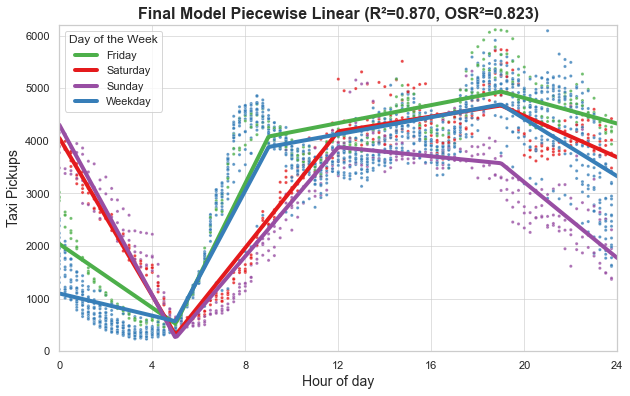

In [32]:
def ensure_day_categorical(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["day"] = pd.Categorical(df["day"], categories=labels, ordered=False)
    return df

def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # breakpoint features
    df["after5"]  = np.maximum(df["hour"] - 5, 0)
    df["after9"]  = np.maximum(df["hour"] - 9, 0)
    df["after12"] = np.maximum(df["hour"] - 12, 0)
    df["after19"] = np.maximum(df["hour"] - 19, 0)
    # day indicators (booleans -> 0/1 in formulas)
    df["is_weekday"]  = (df["day"] == "Weekday")
    df["is_friday"]   = (df["day"] == "Friday")
    df["is_saturday"] = (df["day"] == "Saturday")
    df["is_sunday"]   = (df["day"] == "Sunday")
    # day-specific breakpoint terms
    df["after9_weekday"]   = df["after9"]  * df["is_weekday"]
    df["after9_friday"]    = df["after9"]  * df["is_friday"]
    df["after12_saturday"] = df["after12"] * df["is_saturday"]
    df["after12_sunday"]   = df["after12"] * df["is_sunday"]
    return df

nyc_train2 = add_features(ensure_day_categorical(nyc_train))
nyc_test2  = add_features(ensure_day_categorical(nyc_test))

# model
formula = (
    "pickups ~ hour*C(day)"
    " + after5*C(day)"
    " + after19*C(day)"
    " + after9_weekday + after9_friday"
    " + after12_saturday + after12_sunday"
)

model_all_alt = smf.ols(formula=formula, data=nyc_train2).fit()
r2 = model_all_alt.rsquared

# OSR^2
y_test = nyc_test2["pickups"].to_numpy()
ybar_train = nyc_train2["pickups"].mean()
yhat_test = model_all_alt.predict(nyc_test2)
sse = np.sum((y_test - yhat_test) ** 2)
sst = np.sum((y_test - ybar_train) ** 2)
osr2 = 1 - sse / sst

# Plotting
hours_grid = np.linspace(0, 24, 300)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=nyc_train2, x='hour', y='pickups', hue='day', hue_order=labels, palette=palette,s=10, alpha=0.8, legend=False)

for d in labels:
    grid = pd.DataFrame({"hour": hours_grid, "day": d})
    grid = add_features(ensure_day_categorical(grid))
    yhat = model_all_alt.predict(grid)
    plt.plot(hours_grid, yhat, linewidth=4, label=d, color=palette[d])

plt.title(f"Final Model Piecewise Linear (R²={r2:.3f}, OSR²={osr2:.3f})",fontsize=16, fontweight="bold")
plt.xlabel("Hour of day", fontsize=14)
plt.ylabel("Taxi Pickups", fontsize=14)
plt.xticks(np.arange(0, 25, 4))
plt.yticks(np.arange(0, 6201, 1000))
plt.xlim(0, 24); plt.ylim(0, 6200)
plt.grid(True, alpha=0.6)
plt.legend(title="Day of the Week")
plt.show()


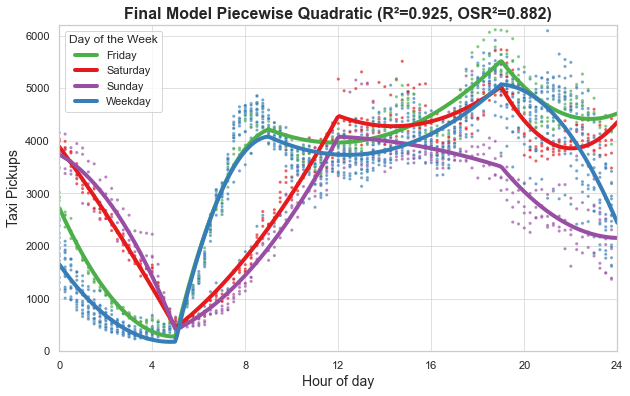

In [33]:
def add_features_quad(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # base & square
    df["hour2"] = df["hour"]**2

    # breakpoints & squares
    df["after5"]  = np.maximum(df["hour"] - 5, 0.0)
    df["after9"]  = np.maximum(df["hour"] - 9, 0.0)
    df["after12"] = np.maximum(df["hour"] - 12, 0.0)
    df["after19"] = np.maximum(df["hour"] - 19, 0.0)

    df["after5_2"]  = df["after5"]**2
    df["after9_2"]  = df["after9"]**2
    df["after12_2"] = df["after12"]**2
    df["after19_2"] = df["after19"]**2

    # day indicators for day-specific terms
    df["is_weekday"]  = (df["day"] == "Weekday")
    df["is_friday"]   = (df["day"] == "Friday")
    df["is_saturday"] = (df["day"] == "Saturday")
    df["is_sunday"]   = (df["day"] == "Sunday")

    # day-specific after9 and after12 (linear + quadratic)
    df["after9_weekday"]    = df["after9"]    * df["is_weekday"]
    df["after9_weekday_2"]  = df["after9_2"]  * df["is_weekday"]
    df["after9_friday"]     = df["after9"]    * df["is_friday"]
    df["after9_friday_2"]   = df["after9_2"]  * df["is_friday"]

    df["after12_saturday"]   = df["after12"]   * df["is_saturday"]
    df["after12_saturday_2"] = df["after12_2"] * df["is_saturday"]
    df["after12_sunday"]     = df["after12"]   * df["is_sunday"]
    df["after12_sunday_2"]   = df["after12_2"] * df["is_sunday"]

    return df

nyc_train_q = add_features_quad(ensure_day_categorical(nyc_train))
nyc_test_q  = add_features_quad(ensure_day_categorical(nyc_test))

# model
formula = (
    "pickups ~ hour*C(day) + hour2*C(day)"
    " + after5*C(day) + after5_2*C(day)"
    " + after19*C(day) + after19_2*C(day)"
    " + after9_weekday + after9_weekday_2 + after9_friday + after9_friday_2"
    " + after12_saturday + after12_saturday_2 + after12_sunday + after12_sunday_2"
)

model_all_alt = smf.ols(formula=formula, data=nyc_train_q).fit()
r2 = model_all_alt.rsquared

# OSR^2
y_test = nyc_test_q["pickups"].to_numpy()
ybar_train = nyc_train_q["pickups"].mean()
yhat_test = model_all_alt.predict(nyc_test_q)
sse = np.sum((y_test - yhat_test) ** 2)
sst = np.sum((y_test - ybar_train) ** 2)
osr2 = 1 - sse / sst

# Plotting
hours_grid = np.linspace(0, 24, 300)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=nyc_train_q, x="hour", y="pickups", hue="day", palette=palette, s=10, alpha=0.7, legend=False)

for d in labels:
    grid = pd.DataFrame({"hour": hours_grid, "day": d})
    grid = add_features_quad(ensure_day_categorical(grid))
    yhat = model_all_alt.predict(grid)
    sns.lineplot(x=hours_grid, y=yhat, linewidth=4, color=palette[d], label=d)

plt.title(f"Final Model Piecewise Quadratic (R²={r2:.3f}, OSR²={osr2:.3f})",fontsize=16, fontweight="bold")
plt.xlabel("Hour of day", fontsize=14)
plt.ylabel("Taxi Pickups", fontsize=14)
plt.xticks(np.arange(0, 25, 4))
plt.yticks(np.arange(0, 6201, 1000))
plt.xlim(0, 24)
plt.ylim(0, 6200)
plt.grid(True, alpha=0.6)
plt.legend(title="Day of the Week")
plt.show()
